## Linear Regression

### Setup and Data Preprocessing

In [5]:
# Data processing and visualisation
import warnings; 
warnings.filterwarnings('ignore'); 
import sys; 
import os; 
sys.stderr = open(os.devnull, 'w')
import numpy as np; 
import pandas as pd; 
import matplotlib.pyplot as plt; 
import seaborn as sns  

In [6]:
# Student performance data
df = pd.read_csv('Student_Performance.csv'); 
df.sample(5) 

,Study Hours,Sleep Hours,Mock Tests,Score
5470,3,6,6,76
2939,1,5,9,86
8419,2,6,5,55
6068,7,7,8,100
4694,8,9,8,100


In [7]:
df.shape  # Size of data

(10000, 4)

In [8]:
tempdf = df.sample(10000)  # Shuffling rows
df = tempdf.iloc[:8000,:]  # Training data
df_test = tempdf.iloc[8000:,:]  # Testing data

In [9]:
y = df['Score'].values  # Observed (actual) values of target

In [10]:
X_s = df['Study Hours'].values  # SLR predictor
print('X_s (Study Hours):', X_s); 
print('y (Score):', y)

X_s (Study Hours): [8 3 3 ... 7 3 5]
y (Score): [100  74  61 ... 100  81  75]


In [11]:
X_m = df.drop('Score', axis = 1).values  # MLR predictors
print('X_m_1 (Study Hours):', X_m[:, 0]); 
print('X_m_2 (Sleep Hours):', X_m[:, 1]); 
print('X_m_3 (Mock Tests):', X_m[:, 2]); 
print('y (Score):', y)

X_m_1 (Study Hours): [8 3 3 ... 7 3 5]
X_m_2 (Sleep Hours): [9 4 5 ... 9 8 7]
X_m_3 (Mock Tests): [8 7 0 ... 2 8 3]
y (Score): [100  74  61 ... 100  81  75]


### Predictions
Simple linear regression model equation is $\hat{y} = \beta_1 x_1 + \beta_0$

Multiple linear regression model equation is $\hat{y} = \beta_1 x_1 + \beta_2 x_2 + ... + \beta_k x_k + \beta_0 = \sum_{j = 1}^{k} \beta_j x_j + \beta_0$

In [12]:
# Function to predict target values using inputs and coefficients
def predictions(X, B):
    X = np.array(X)
    if X.ndim == 1: X = X.reshape(-1, 1)  # 1D array -> 2D array
    X_d = np.hstack([np.ones((X.shape[0], 1)), X])  # Add ones for intercept
    B = np.array(B)
    y_pred = np.dot(X_d, B)
    return y_pred

In [13]:
y_pred_s = predictions(X_s, [2, 1]); y_pred_s  # Predictions for all data points for some B0, B1

array([10.,  5.,  5., ...,  9.,  5.,  7.])

In [14]:
y_pred_m = predictions(X_m, [2, 1, 3, 4]); y_pred_m  # Predictions for all data points for some B0, B1, B2, B3

array([69., 45., 20., ..., 44., 61., 40.])

### Residuals / Errors
Error or residual is $e = y - \hat{y}$

In [15]:
errors_s = y - y_pred_s  # Errors or residuals
pd.DataFrame({'Study Hours': X_s, 'Actual Score': y, 'Predicted Score': y_pred_s, 'Error': errors_s}).head()

,Study Hours,Actual Score,Predicted Score,Error
0,8,100,10.0,90.0
1,3,74,5.0,69.0
2,3,61,5.0,56.0
3,2,96,4.0,92.0
4,4,73,6.0,67.0


In [16]:
# Function to visualise errors in SLR case
def visualise_errors(X, y, B, samples = 5):
    # Processing inputs and coefficients
    X = np.array(X).reshape(-1, 1)
    indices = np.random.choice(len(X), size = min(samples, len(X)), replace = False); X_sample = X[indices]; y_sample = y[indices]
    X_d = np.hstack([np.ones((X_sample.shape[0], 1)), X_sample]); B = np.array(B)

    # Predictions
    y_pred = np.dot(X_d, B); X_sample = X_sample.flatten()

    # Plotting errors
    plt.figure(figsize = (8, 3))
    sns.scatterplot(x = X_sample, y = y_sample, color = 'blue', label = 'Actual')
    sns.scatterplot(x = X_sample, y = y_pred, color = 'red', label = 'Predicted')
    for i in range(len(X_sample)): plt.plot([X_sample[i], X_sample[i]], [y_sample[i], y_pred[i]], linestyle = 'dotted', color = 'grey', linewidth = 1)
    plt.xlabel('x'); plt.ylabel('y'); plt.title('Actuals vs Predicted'); plt.legend(bbox_to_anchor = (1.25, 1)); plt.tight_layout()

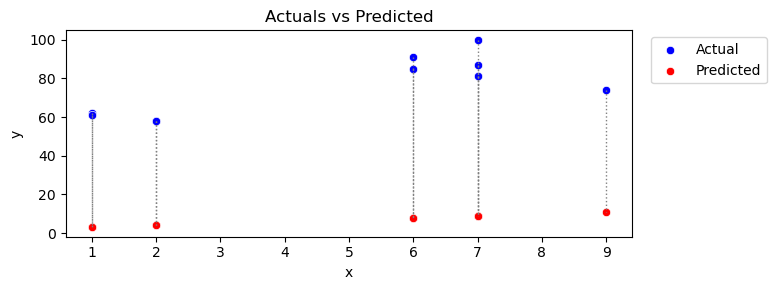

In [17]:
visualise_errors(X_s, y, [2, 1], 10)  # See errors for samples from the data

In [18]:
errors_m = y - y_pred_m  # Errors or residuals
pd.DataFrame({'Study Hours': X_m[:, 0], 'Sleep Hours': X_m[:, 1] , 'Mock Tests': X_m[:, 2], 'Actual Score': y, 'Predicted Score': y_pred_m, 'Error': errors_m}).head()

,Study Hours,Sleep Hours,Mock Tests,Actual Score,Predicted Score,Error
0,8,9,8,100,69.0,31.0
1,3,4,7,74,45.0,29.0
2,3,5,0,61,20.0,41.0
3,2,5,8,96,51.0,45.0
4,4,6,2,73,32.0,41.0


### Residual Sum of Squares (RSS) / Mean Squared Error (MSE)
Mathematically, $\mathrm{MSE} = \frac{\mathrm{RSS}}{n} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

In [19]:
def mse(errors): return np.mean(errors ** 2)  # Mean of squared errors

In [21]:
mse_s = mse(errors_s); 
print(f'MSE for SLR =', mse_s); 
mse_m = mse(errors_m); 
print(f'MSE for MLR =', mse_m)

MSE for SLR = 5567.58275
MSE for MLR = 1425.094375


### Coefficients and MSEs

In [22]:
# Function to predict target values using inputs and coefficients
def predict_and_mse(X, y, B):
    X = np.array(X)
    if X.ndim == 1 : X = X.reshape(-1, 1)
    X_d = np.hstack([np.ones((X.shape[0], 1)), X]); B = np.array(B)
    y_pred = np.dot(X_d, B); errors = y - y_pred; mse = np.mean(errors ** 2)
    return mse

In [23]:
predict_and_mse(X_s, y, [10, 3])  # SLR MSEs for various coefficient values

3196.10525

In [24]:
predict_and_mse(X_m, y, [2, -2, 5, 8])  # SLR MSEs for various coefficient values

980.4635

### Optimum Coefficient Values - Loops

In [25]:
# Arbitrary coefficients and associated MSEs using loops - SLR
for i in np.arange(-1, 1, 0.25):
    for j in np.arange(0, 5, 0.1):
        print('Coefficients = {} & MSE = {}'.format([float(np.round(i, 1)), float(np.round(j, 1))], np.round(predict_and_mse(X_s, y, [i, j]), 2)))

Coefficients = [-1.0, 0.0] & MSE = 6852.83
Coefficients = [-1.0, 0.1] & MSE = 6766.24
Coefficients = [-1.0, 0.2] & MSE = 6680.28
Coefficients = [-1.0, 0.3] & MSE = 6594.96
Coefficients = [-1.0, 0.4] & MSE = 6510.27
Coefficients = [-1.0, 0.5] & MSE = 6426.21
Coefficients = [-1.0, 0.6] & MSE = 6342.79
Coefficients = [-1.0, 0.7] & MSE = 6260.0
Coefficients = [-1.0, 0.8] & MSE = 6177.84
Coefficients = [-1.0, 0.9] & MSE = 6096.31
Coefficients = [-1.0, 1.0] & MSE = 6015.42
Coefficients = [-1.0, 1.1] & MSE = 5935.16
Coefficients = [-1.0, 1.2] & MSE = 5855.53
Coefficients = [-1.0, 1.3] & MSE = 5776.54
Coefficients = [-1.0, 1.4] & MSE = 5698.18
Coefficients = [-1.0, 1.5] & MSE = 5620.45
Coefficients = [-1.0, 1.6] & MSE = 5543.35
Coefficients = [-1.0, 1.7] & MSE = 5466.89
Coefficients = [-1.0, 1.8] & MSE = 5391.06
Coefficients = [-1.0, 1.9] & MSE = 5315.86
Coefficients = [-1.0, 2.0] & MSE = 5241.3
Coefficients = [-1.0, 2.1] & MSE = 5167.36
Coefficients = [-1.0, 2.2] & MSE = 5094.06
Coefficients 

In [26]:
# Arbitrary coefficients and associated MSEs using loops - MLR
for i in np.arange(0, 1, 0.25):
    for j in np.arange(0, 3, 0.5):
        for k in np.arange(-2, 10, 0.5):
            for l in np.arange(0, 1, 0.5):
                print('Coefficients = {} & MSE = {}'.format([float(np.round(i, 1)), float(np.round(j, 1)), float(np.round(k, 1)), float(np.round(l, 1))], np.round(predict_and_mse(X_m, y, [i, j, k, l]), 2)))

Coefficients = [0.0, 0.0, -2.0, 0.0] & MSE = 8984.97
Coefficients = [0.0, 0.0, -2.0, 0.5] & MSE = 8545.54
Coefficients = [0.0, 0.0, -1.5, 0.0] & MSE = 8377.53
Coefficients = [0.0, 0.0, -1.5, 0.5] & MSE = 7953.02
Coefficients = [0.0, 0.0, -1.0, 0.0] & MSE = 7792.82
Coefficients = [0.0, 0.0, -1.0, 0.5] & MSE = 7383.22
Coefficients = [0.0, 0.0, -0.5, 0.0] & MSE = 7230.83
Coefficients = [0.0, 0.0, -0.5, 0.5] & MSE = 6836.14
Coefficients = [0.0, 0.0, 0.0, 0.0] & MSE = 6691.56
Coefficients = [0.0, 0.0, 0.0, 0.5] & MSE = 6311.79
Coefficients = [0.0, 0.0, 0.5, 0.0] & MSE = 6175.02
Coefficients = [0.0, 0.0, 0.5, 0.5] & MSE = 5810.17
Coefficients = [0.0, 0.0, 1.0, 0.0] & MSE = 5681.2
Coefficients = [0.0, 0.0, 1.0, 0.5] & MSE = 5331.26
Coefficients = [0.0, 0.0, 1.5, 0.0] & MSE = 5210.11
Coefficients = [0.0, 0.0, 1.5, 0.5] & MSE = 4875.09
Coefficients = [0.0, 0.0, 2.0, 0.0] & MSE = 4761.74
Coefficients = [0.0, 0.0, 2.0, 0.5] & MSE = 4441.63
Coefficients = [0.0, 0.0, 2.5, 0.0] & MSE = 4336.09
Coeff

### Optimum Coefficient Values - Ordinary Least Squares (OLS)
Optimum slope and intercept using OLS for SLR are $\hat{\beta_1} = \frac{\mathrm{COV}(X,\, y)} {\mathrm{VAR}(X)} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}$ and $\hat{\beta_0} = \bar{y} - \hat{\beta_1} \bar{x}$

Optimum coefficients using OLS for MLR are $\beta = (X^T X)^{-1} X^T y$, where $X$ is $[1\, X]$, and this is called the normal equation that minimises the RSS

In [27]:
x_mean = np.mean(X_s); y_mean = np.mean(y)  # Means
beta_1 = np.sum((X_s - x_mean) * (y - y_mean)) / np.sum((X_s - x_mean) ** 2)  # B1
beta_0 = y_mean - beta_1 * x_mean  # B0

In [28]:
print('B1 = {}\nB0 = {}'.format(np.round(beta_1, 4), np.round(beta_0, 4)))  # Optimum coefficients using OLS for SLR

B1 = 4.38
B0 = 58.2603


In [29]:
predict_and_mse(X_s, y, [beta_0, beta_1])  # MSE from OLS for SLR

141.59953853864593

In [30]:
def predict_and_mse_ols(X, y):
    X = np.array(X)
    if X.ndim == 1 : X = X.reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)
    X_d = np.hstack((np.ones((X.shape[0], 1)), X))
    
    # Compute OLS coefficients using the normal equation
    Xt = np.transpose(X_d); XtX = np.dot(Xt, X_d); XtX_inv = np.linalg.inv(XtX); XtY = np.dot(Xt, y); B = np.dot(XtX_inv, XtY)
    
    # Predictions and MSE
    y_pred = np.dot(X_d, B); mse = np.mean((y - y_pred) ** 2)
    
    return B, mse

In [31]:
predict_and_mse_ols(X_s, y)  # MSE from OLS for SLR

(array([[58.2602958 ],
        [ 4.38003138]]),
 141.59953853864596)

In [32]:
predict_and_mse_ols(X_m, y)  # MSE from OLS for MLR

(array([[36.71604715],
        [ 4.30408958],
        [ 1.62929213],
        [ 2.47287486]]),
 83.4342465006664)

### Optimum Coefficient Values - Gradient Descent (GD)
The gradient descent algorithm is as follows
1. Start with some random initial coefficients $\beta_0$, $\beta_1$, ..., $\beta_k$<br>

2. Compute predictions $\hat{y} = \beta_0 + \beta_1 x_1 + ... + \beta_k x_k$
3. Compute gradients $\frac{\partial J}{\partial \beta}$ = $\frac{2\alpha}{n} \sum_{i = 1}^{n}(y_i - \hat{y}_i) x_{i}$, where $\alpha$ is the learning rate
4. Update parameters using $\beta_0 := \beta_0 + \alpha \frac{\partial J}{\partial \beta_0}$ and $\beta_k := \beta_k + \alpha \frac{\partial J}{\partial \beta_k}$
5. Repeat until the cost $J(\beta)$ converges under some criterion

In [33]:
# Function to compute optimum coefficients using GD and track MSEs
def predict_and_mse_gd(X, y, B, learning_rate = 0.01, steps = 100, tolerance = 0.01):
    # Processing inputs
    X = np.array(X)
    if X.ndim == 1: X = X.reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)
    n, p = X.shape  # Number of observations and predictors
    X_d = np.hstack([np.ones((n, 1)), X])
    B = np.array(B, dtype = float).reshape(-1, 1)

    # Gradient descent iterations
    prev_loss = None
    history = []
    for step in range(steps):
        y_pred = np.dot(X_d, B)  # Predictions
        error = y - y_pred  # Errors
        loss = (1 / n) * np.sum(error ** 2)  # Loss
        gradient = (2 / n) * np.dot(X_d.T, error)  # Gradient
        B += learning_rate * gradient  # Update coefficients
        history.append(B.flatten().tolist() + [loss])  # Current coefficients and associated loss

        # Early stopping
        if prev_loss is not None and abs((loss - prev_loss) / prev_loss) < tolerance: break
        prev_loss = loss
    
    gd_history = pd.DataFrame(history, columns = [f'B{i}' for i in range(B.shape[0])] + ['MSE'])  # GD history
    gd_history.index.name = 'Iteration'
    
    return gd_history

In [34]:
predict_and_mse_gd(X_s, y, [1, 1], 0.02, 1000, 0.0001).tail(5)  # GD results for SLR

,B0,B1,MSE
Iteration,,,
396,56.208870,4.705944,142.505925
397,56.225824,4.703250,142.491005
398,56.242639,4.700579,142.476330
399,56.259314,4.697930,142.461897
400,56.275851,4.695302,142.447702


In [35]:
predict_and_mse_gd(X_m, y, [1, 1, 1, 1], 0.0105, 1000, 0.0001).tail(5)  # GD results for MLR

,B0,B1,B2,B3,MSE
Iteration,,,,,
995,23.142147,4.747494,3.046095,2.800510,91.912017
996,23.155114,4.747276,3.045001,2.800388,91.895875
997,23.167993,4.746652,3.043400,2.799888,91.879764
998,23.180934,4.746430,3.042303,2.799763,91.863684
999,23.193789,4.745811,3.040710,2.799267,91.847634


### R-Squared
Mathematically, $R^2 = 1 - \frac{\mathrm{RSS}}{\mathrm{TSS}}= 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$

In [36]:
# Function to compute R-squared
def r2(X, y, B):
    # Processing inputs and predictions
    X = np.array(X)
    if X.ndim == 1: X = X.reshape(-1, 1)
    X_d = np.hstack([np.ones((X.shape[0], 1)), X]); B = np.array(B)
    y_pred = np.dot(X_d, B)

    # Computing R-squared
    TSS = np.sum((y - np.mean(y)) ** 2)  # Total sum of squares
    RSS = np.sum((y - y_pred) ** 2)  # Residual sum of squares
    R2val = 1 - (RSS / TSS)  # R-squared
    
    return R2val

In [37]:
r2(X_s, y, predict_and_mse_ols(X_s, y)[0].T.reshape(-1))  # R-squared for SLR

0.47587274920882816

In [38]:
r2(X_m, y, predict_and_mse_ols(X_m, y)[0].T.reshape(-1))  # R-squared for MLR

0.6911701641718825

### Adjusted R-Squared
Mathematically, $R^2_{\mathrm{adj}} = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$, where $n$ is the number of data points and $p$ is the number of predictors

In [39]:
# Function to compute R-squared
def r2adj(r2, n, p): return 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [40]:
r2adj(r2(X_s, y, predict_and_mse_ols(X_s, y)[0].T.reshape(-1)), 8000, 1)  # Adjusted R-squared for SLR

0.47580721691940686

In [41]:
r2adj(r2(X_m, y, predict_and_mse_ols(X_m, y)[0].T.reshape(-1)), 8000, 3)  # Adjusted R-squared for SLR

0.6910542950488854

### MSE as a Predictive Performance Measure

In [42]:
predict_and_mse(X_s, y, predict_and_mse_ols(X_s, y)[0].T.reshape(-1))  # SLR MSE on training data

141.59953853864596

In [43]:
predict_and_mse(df_test['Study Hours'].values, df_test['Score'].values, predict_and_mse_ols(X_s, y)[0].T.reshape(-1))  # SLR MSE on testing data

146.27137990083594

In [44]:
predict_and_mse(X_m, y, predict_and_mse_ols(X_m, y)[0].T.reshape(-1))  # MLR MSE on training data

83.4342465006664

In [45]:
predict_and_mse(df_test.drop('Score', axis = 1).values, df_test['Score'].values, predict_and_mse_ols(X_m, y)[0].T.reshape(-1))  # SLR MSE on testing data

83.63333066443525